[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch11.ipynb)

Notebook Bab 11 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Teks perlu diubah menjadi representasi numerik. Kita memakai UCI SMS Spam untuk membandingkan BoW, TF-IDF kata, TF-IDF karakter, dan risiko duplikasi lintas split.


## Persiapan


In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


## Section 1 - Demo: Representasi Sparse pada SMS Spam


## Data: pesan pendek berlabel spam/ham

SMS Spam Collection adalah korpus kecil dan imbalanced. Pesan tidak tersusun kronologis, sehingga demo memakai split acak terstratifikasi dan split sadar-duplikasi, bukan split waktu.


In [2]:
DATA_DIR = section_data_dir('ch11_sms_spam')
sms = pd.read_parquet(DATA_DIR / 'sms_spam.parquet')
stats = json.loads((DATA_DIR / 'verified_stats.json').read_text(encoding='utf-8'))

print(f"Rows: {stats['rows']:,} | raw labeled lines: {stats['raw_labeled_lines']:,} | missing cells: {stats['missing_cells']}")
print(f"Label counts: {stats['label_counts']} | spam rate: {stats['spam_rate']:.3f}")
print(f"CountVectorizer vocab: {stats['count_vectorizer_vocabulary_size']:,} | density: {stats['count_vectorizer_density']:.6f}")
print(f"Duplicate normalized-text rows after first: {stats['duplicate_text_rows_after_first']:,}")
print(f"Random split train/test text overlap: {stats['random_split_train_test_text_overlap_count']:,}")


Rows: 5,574 | raw labeled lines: 5,574 | missing cells: 0
Label counts: {'ham': 4827, 'spam': 747} | spam rate: 0.134
CountVectorizer vocab: 8,444 | density: 0.000926
Duplicate normalized-text rows after first: 415
Random split train/test text overlap: 141


## Class imbalance dan sparsity

Spam hanya sekitar 13% dari data. Representasi BoW dan TF-IDF juga sangat sparse: hampir semua dokumen hanya mengisi sedikit kolom vocabulary.


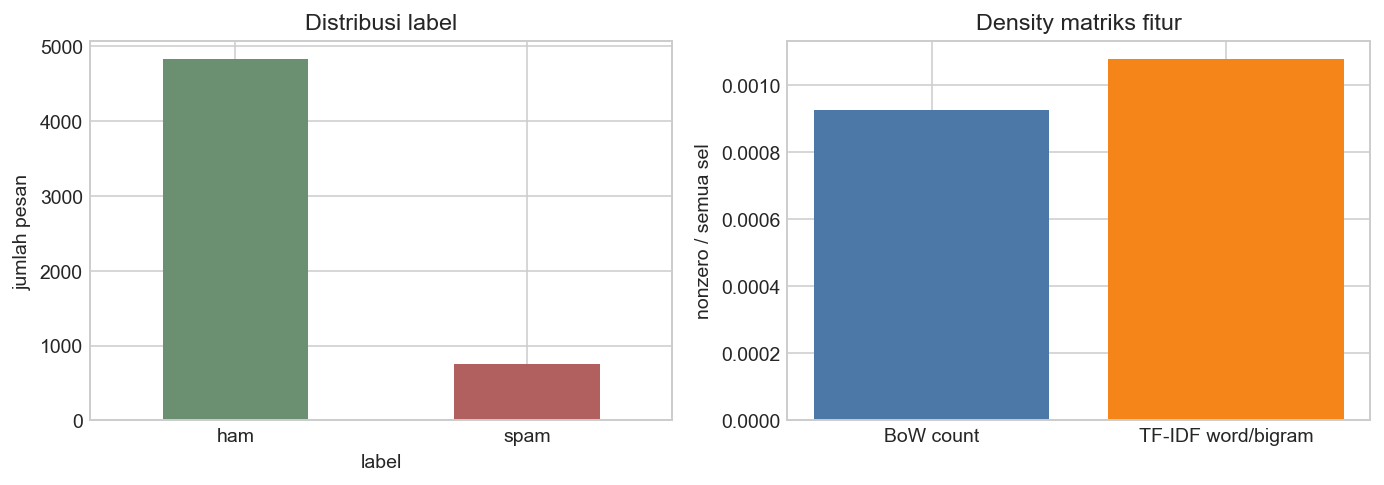

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
sms['label'].value_counts().loc[['ham', 'spam']].plot(kind='bar', ax=axes[0], color=['#6b8f71', '#b25f5f'])
axes[0].set_title('Distribusi label')
axes[0].set_ylabel('jumlah pesan')
axes[0].tick_params(axis='x', rotation=0)
axes[1].bar(['BoW count', 'TF-IDF word/bigram'], [stats['count_vectorizer_density'], stats['tfidf_word_bigram_density']], color=['#4c78a8', '#f58518'])
axes[1].set_title('Density matriks fitur')
axes[1].set_ylabel('nonzero / semua sel')
plt.tight_layout()
plt.show()


## BoW vs TF-IDF kata vs TF-IDF karakter

Semua representasi memakai pengklasifikasi yang sama. `DummyClassifier` memberi lantai metrik untuk dataset imbalanced.


representasi  Average Precision  ROC_AUC     F1
       dummy             0.1341   0.5000 0.0000
   BoW count             0.9765   0.9889 0.9468
 TF-IDF word             0.9753   0.9886 0.9162
 TF-IDF char             0.9858   0.9949 0.9648


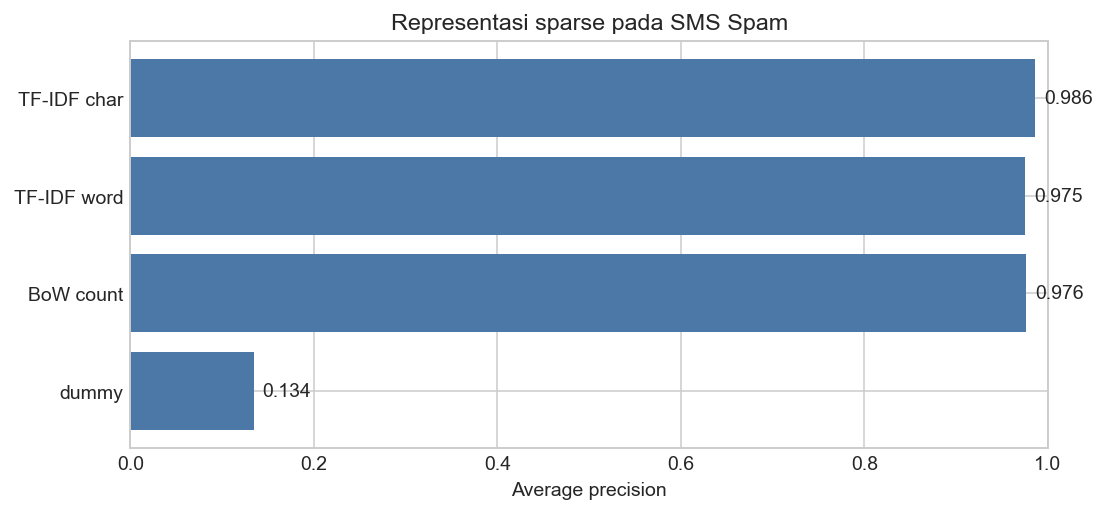

In [4]:
train_sms, test_sms = train_test_split(sms, test_size=0.25, stratify=sms['is_spam'], random_state=RANDOM_STATE)
models = {
    'dummy': DummyClassifier(strategy='most_frequent'),
    'BoW count': Pipeline([('vec', CountVectorizer(lowercase=True, stop_words='english')), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))]),
    'TF-IDF word': Pipeline([('vec', TfidfVectorizer(lowercase=True, stop_words='english', min_df=2, ngram_range=(1, 2))), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))]),
    'TF-IDF char': Pipeline([('vec', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2)), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))]),
}
rows = []
for name, pipe in models.items():
    pipe.fit(train_sms['text'], train_sms['is_spam'])
    score = pipe.predict_proba(test_sms['text'])[:, 1]
    pred = pipe.predict(test_sms['text'])
    rows.append({
        'representasi': name,
        'Average Precision': average_precision_score(test_sms['is_spam'], score),
        'ROC_AUC': roc_auc_score(test_sms['is_spam'], score),
        'F1': f1_score(test_sms['is_spam'], pred, zero_division=0),
    })
metrics = pd.DataFrame(rows)
print(metrics.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(metrics['representasi'], metrics['Average Precision'], color='#4c78a8')
ax.set_xlim(0, 1)
ax.set_xlabel('Average precision')
ax.set_title('Representasi sparse pada SMS Spam')
for i, value in enumerate(metrics['Average Precision']):
    ax.text(value + 0.01, i, f'{value:.3f}', va='center')
plt.tight_layout()
plt.show()


## Duplikasi lintas split

Beberapa SMS muncul berulang. Jika teks identik muncul di train dan test, model bisa terlihat lebih memahami bahasa daripada kenyataannya. Split berbasis grup menjaga teks normalisasi yang sama tetap berada di satu sisi saja.


In [5]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(sms, sms['is_spam'], groups=sms['text_norm']))
gtrain = sms.iloc[train_idx]
gtest = sms.iloc[test_idx]
pipe = Pipeline([
    ('vec', TfidfVectorizer(lowercase=True, stop_words='english', min_df=2, ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
])
pipe.fit(gtrain['text'], gtrain['is_spam'])
gscore = pipe.predict_proba(gtest['text'])[:, 1]
gpred = pipe.predict(gtest['text'])
random_tfidf = metrics.loc[metrics['representasi'] == 'TF-IDF word'].iloc[0]
group_row = {
    'representasi': 'TF-IDF word, duplicate-aware split',
    'Average Precision': average_precision_score(gtest['is_spam'], gscore),
    'ROC_AUC': roc_auc_score(gtest['is_spam'], gscore),
    'F1': f1_score(gtest['is_spam'], gpred),
}
compare = pd.DataFrame([random_tfidf.to_dict(), group_row])
print(compare.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


                      representasi  Average Precision  ROC_AUC     F1
                       TF-IDF word             0.9753   0.9886 0.9162
TF-IDF word, duplicate-aware split             0.9705   0.9917 0.9185


>
> 🔎 **Amati.** Sparse text features already perform strongly on SMS Spam. Character n-grams are especially useful for short, noisy SMS because they can catch fragments, spelling variants, and phone-number-like patterns. The duplicate-aware split keeps identical texts from crossing train/test; the metric stays strong here, but the overlap count shows why duplication must be checked explicitly.


## Section 2 - Mini Project

## Soal

Anda diberi data ulasan produk berbahasa Indonesia (`data/ch11_reviews.csv`, kolom `teks` dan `label` dengan 1 = positif, 0 = negatif).

Tugas:

1. Bangun *pipeline* klasifikasi sentimen berbasis **TF-IDF** + regresi logistik. Pastikan *vectorizer* berada di dalam *pipeline* agar kosakata hanya di-*fit* dari data *training* (hindari *vocabulary leakage*).
2. Bangun pembanding berbasis **embedding** (boleh SBERT multibahasa, misalnya `paraphrase-multilingual-MiniLM-L12-v2`) + regresi logistik.
3. Bandingkan akurasi keduanya dan jelaskan kapan tiap representasi lebih unggul.

**Catatan *leakage*:** periksa apakah ada teks duplikat yang bisa bocor melintasi *split*; jika ada, lakukan deduplikasi atau *group split* berdasarkan sumber.

**Luaran:** kode kedua *pipeline*, tabel akurasi, dan 3-4 kalimat analisis.

**Kriteria penilaian:** (a) tidak ada *fit* *vectorizer* pada data uji; (b) perbandingan adil (pengklasifikasi sama); (c) analisis menyebut trade-off *sparse* vs *dense*. Catatan: dataset ini kecil, jadi sebutkan keterbatasannya pada analisis Anda.

In [6]:
import os
import pandas as pd

# Memuat data awal. Pakai berkas lokal bila ada; jika tidak (mis. di Colab), unduh dari GitHub.
path = 'data/ch11_reviews.csv'
if not os.path.exists(path):
    path = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/ch11_reviews.csv'
reviews = pd.read_csv(path)
print('Jumlah ulasan:', len(reviews))
print('Distribusi label:', reviews['label'].value_counts().to_dict())
reviews.head()

Jumlah ulasan: 30
Distribusi label: {1: 15, 0: 15}


,teks,label
0,Barangnya sesuai foto dan pengirimannya cepat ...,1
1,"Kualitas bahan terasa premium, jahitannya rapi",1
2,"Sudah dipakai seminggu, baterainya awet sehari...",1
3,Pelayanan penjualnya ramah dan responsif saat ...,1
4,Harga segini dapat kualitas seperti ini jelas ...,1


In [7]:
# Kerjakan di sini.
# Bangun dua pipeline (TF-IDF dan embedding), latih, lalu bandingkan akurasinya.
